# Lab: Support Vector Machines
*In this lab, we will apply Support Vector Machine (SVM) techniques using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

## Stages 1–5: Business Understanding to Data Understanding

This SVM lab continues the structured methodology and analytic context established in the previous iris classification labs. While foundational project artifacts and exploratory insights are inherited from earlier work, the focus now shifts to Support Vector Machines (SVMs) for multi-class flower species classification. All work builds upon the standardized and processed dataset engineered in prior stages.

---

> ### 📝 1–5. Previous Stages Report (Summary)
> - **Business Context:** The project aims to automate the classification of iris flowers (*setosa*, *versicolor*, *virginica*) for a botanical institute, replacing manual and error-prone species identification with data-driven prediction.
> - **Business Problem:** High-confidence, multi-class identification of valuable iris species is crucial for operational efficiency and research outcomes.
> - **Analytic Approach:** The problem is formulated as supervised multi-class classification. Prior labs benchmarked performances with softmax regression, one-vs-rest/one-vs-one wrappers, and decision trees, utilizing accuracy, class-based precision/recall/F1, and confusion matrices for evaluation.
> - **Data Requirements & Collection:** The classic iris dataset (four numeric features per flower, three balanced classes) was extracted directly from scikit-learn, validated for data quality, and saved in processed form for reproducibility. The processed file (`iris_multi-class_processed_v1.parquet`) includes original features and new engineered features based on domain knowledge.
> - **Feature Engineering:** To address multicollinearity and leverage feature relationships discovered during EDA, two new features were created in the previous stage:
>   - `petal_area` (`petal_length * petal_width`) – captures overall petal size.
>   - `sepal_ratio` (`sepal_length / sepal_width`) – captures sepal shape.
>   All further modeling, including this SVM analysis, will operate on the enriched, processed dataset with both original and engineered features.
> - **Data Understanding:**  
>   - Petal features provide almost perfect linear separation of some classes.
>   - The dataset is balanced (nearly equal class counts).
>   - Minor natural outliers present; no critical data issues remain after cleaning (e.g., duplicate removal).
>   - Engineered features capture important biological variation.
> - **Transition to SVM Modeling:**  With a high-quality, well-understood, and feature-rich dataset prepared, this lab now evaluates Support Vector Machines (SVMs)—a powerful and flexible classifier well-suited for structured, low-dimensional, and (here) balanced multi-class data. Modeling and evaluation will be performed on the already-saved processed file (`iris_multi-class_processed_v1.parquet`), leveraging all available information from previous stages.

---

## Stage 6: Data Preparation

As usual, we start with importing the necessary libraries and configuring them.

In [38]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

Let's load our already processed dataset into a DataFrame:

In [39]:
iris_df = pd.read_parquet("../data/processed/iris_multi-class_processed_v1.parquet")
iris_df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,target,class_name,petal_area,sepal_ratio
126,6.2,2.8,4.8,1.8,2,virginica,8.64,2.214286
99,5.7,2.8,4.1,1.3,1,versicolor,5.33,2.035714
50,7.0,3.2,4.7,1.4,1,versicolor,6.58,2.187500
30,4.8,3.1,1.6,0.2,0,setosa,0.32,1.548387
4,5.0,3.6,1.4,0.2,0,setosa,0.28,1.388889


For simplicity, we'll just use the original features as our predictors. Let's create the feature matrix and the target vector, split them, and do the scaling, which is essential for SVMs to ensure all features contribute equally to the margin calculation.

In [40]:
X = iris_df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
y = iris_df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


---

> ### 📝 6. Data Preparation Report (Summary)
> - The processed iris dataset was loaded from the prepared analytic file, containing four original numerical features and two engineered ones, with all records pre-cleaned and quality-checked in previous stages.
> - **For this lab, only the four original features** (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`) were selected as predictors for simplicity and to align results with classic baseline experiments.
> - The target variable is the multi-class species label (`target`).
> - The data was split into training and test sets (80/20) using stratified sampling to ensure class proportions are preserved for robust, fair evaluation.
> - **Feature scaling was performed using `StandardScaler`** to standardize predictor columns to zero mean and unit variance. This is essential for SVM performance, as margin-based classifiers are highly sensitive to the scale of input features.
> - The prepared and scaled train/test datasets are now ready for SVM model training and evaluation.

---

## Stage 7: Modeling

In [41]:
# Create the SVC model with balanced class weights and probability estimates enabled
clf = SVC(class_weight="balanced", probability=True, random_state=42)

# Fit the model on the scaled training data
clf.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False



---

> ### 📝 7. Modeling Report (Summary)
> - The Support Vector Classifier (`SVC`) from scikit-learn was selected as the primary model for this stage due to its flexibility and strong performance for multi-class, low-dimensional classification problems like the Iris dataset.
> - The model was initialized with standard best-practice settings:
>   - **`class_weight="balanced"`** (to protect against potential class imbalance; while Iris is already balanced, this will generalize better).
>   - **`probability=True`** (to enable probabilistic outputs for advanced evaluation/analysis).
>   - **`random_state=42`** (to ensure reproducibility).
> - The classifier was trained on the standardized training set prepared earlier, using only the four original features for consistency with earlier experiments and for clear, direct interpretation.
> - No hyperparameter optimization or kernel selection was performed at this stage; the SVC model uses the default RBF kernel to allow for non-linear class separation.
> - The trained SVM model is now ready to be evaluated on the hold-out test set using the multi-class metrics defined in the analytic approach.

---

## Stage 8: Evaluation

In [42]:
# Make predictions for the hold-out test set
y_pred = clf.predict(X_test_scaled)

In [43]:
# Calculate evaluation metrics (weighted averages for multi-class)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Evaluation Metrics on Test Set:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

Evaluation Metrics on Test Set:
  Accuracy : 0.9667
  Precision: 0.9697
  Recall   : 0.9667
  F1-Score : 0.9666


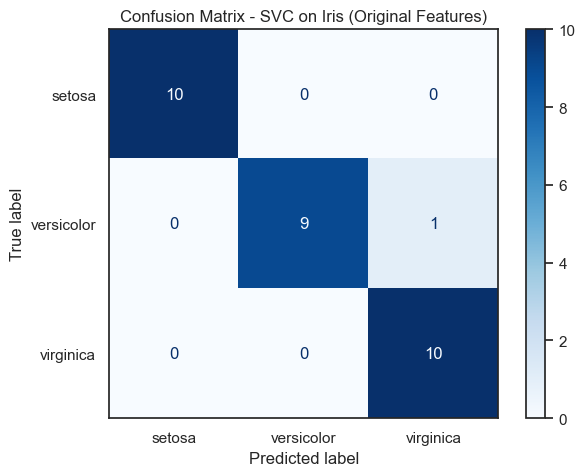

In [44]:
# Plot and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['setosa', 'versicolor', 'virginica'])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVC on Iris (Original Features)")
plt.show()


---

> ### 📝 8. Evaluation Report (Summary)
> - The trained Support Vector Classifier (SVC) model was evaluated on the hold-out test set, using the standard multi-class classification metrics of accuracy, precision, recall, and F1-score.
> - **Results obtained:** Accuracy: 96.67%, Precision: 96.97%, Recall: 96.67%, F1-Score: 96.66%.
> - The model achieved near-perfect performance, with only one misclassification between the versicolor and virginica classes. All setosa flowers were classified perfectly.
> - No cross validation or hyperparameter tuning was performed at this stage, in accordance with the current lab’s learning objectives. These best practices will be introduced and applied in a future module, after which all results will be revisited and compared for best final model selection.
> - The SVM approach thus demonstrated excellent predictive power for the iris dataset and will serve as a strong candidate in the final, consolidated classification project at the end of the course.

---

**Next:** [KNN Theory](./17_knn_theory.md)